In [1]:
from astropy.io import fits
from astropy.table import Table
import numpy as np
#import matplotlib.pyplot as plt

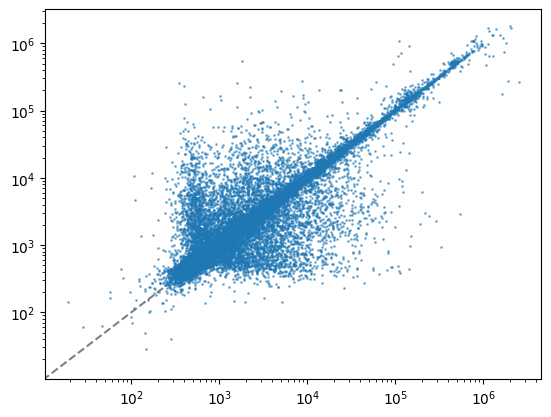

In [2]:
big_table = '/orange/adamginsburg/jwst/cloudc/catalogs/f212n_merged_indivexp_merged_dao_basic_allcols.fits'
with fits.open(big_table, memmap=True) as hdul:
    data = hdul[1].data   # this is a memmapped FITS_rec

    # Step 1: read only the column needed for filtering
    col = data["detector"]   # NOT copied into RAM

    mask = [any('nrca' in x for x in row) and (any('nrcb' in x for x in row)) for row in col]

    data = hdul[1].data[mask]
    tbl = Table(data)

mask_a = np.char.find(tbl['detector'], 'nrca') >= 0
mask_b = np.char.find(tbl['detector'], 'nrcb') >= 0


flux_a = np.ma.masked_array(tbl['flux_fit'], mask=~mask_a).mean(axis=1)
flux_b = np.ma.masked_array(tbl['flux_fit'], mask=~mask_b).mean(axis=1)

import pylab as pl
pl.scatter(flux_a, flux_b, s=1, alpha=0.5);
pl.plot([0,1e5],[0,1e5], 'k--', alpha=0.5, zorder=-1)
pl.loglog();

/orange/adamginsburg/miniconda3/envs/python312/lib/python3.12/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


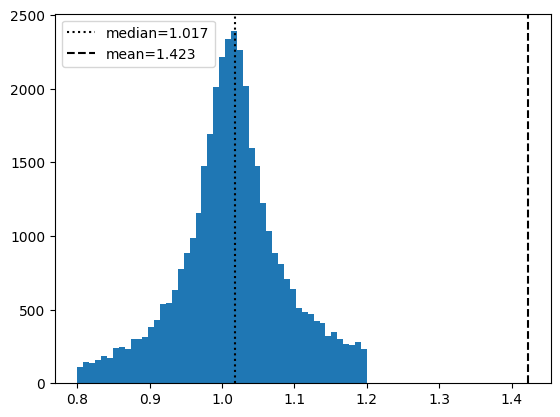

In [3]:
pl.figure()
pl.hist(flux_b / flux_a, bins=np.linspace(0.8, 1.2));
med, mean = np.nanmedian(flux_b / flux_a), np.nanmean(flux_b / flux_a)
pl.axvline(med, label=f'median={med:0.3f}', linestyle=':', color='k')
pl.axvline(mean, label=f'mean={mean:0.3f}', linestyle='--', color='k')
pl.legend(loc='best');